In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import datetime
import traceback
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.sparse import csr_matrix

# Input file path (make sure using most recent aligned anndatas)
GE_INPUT = ""
SPLICE_INPUT = ""

# Read the input file
ge_adata = ad.read_h5ad(GE_INPUT)
ge_adata.var_names = ge_adata.var["gene_name"]

splice_adata = ad.read_h5ad(SPLICE_INPUT)

# Check the number of cells and genes
print(f"Number of cells: {ge_adata.n_obs}")
print(f"Number of genes: {ge_adata.n_vars}")

Number of cells: 157418
Number of genes: 19022


In [2]:
ge_adata.obs.head()

,cell_id,age,cell_ontology_class,mouse.id,sex,tissue,dataset,batch,subtissue_clean,broad_cell_type,cell_id_index,cell_name,library_size
98264,A10_B000120,18m,basal epithelial cell of tracheobronchial tree,18_47_F,female,Trachea,tabula_muris_senis,tabula_muris_senis,nan,EPITHELIAL CELL,0,A10_B000120,59.409354
138404,A10_B000126,3m,bulge keratinocyte,3_39_F,female,Skin,tabula_muris_senis,tabula_muris_senis,Telogen,KERATINOCYTE,1,A10_B000126,234.908896
138405,A10_B000127,3m,myeloid cell,3_38_F,female,SCAT,tabula_muris_senis,tabula_muris_senis,Fat,MYELOID IMMUNE CELL,2,A10_B000127,186.789788
138406,A10_B000166,3m,basal cell,3_56_F,female,Mammary_Gland,tabula_muris_senis,tabula_muris_senis,Mammary_Gland,BASAL CELL,3,A10_B000166,1558.667439
103042,A10_B000169,18m,endothelial cell of coronary artery,18_53_M,male,Heart,tabula_muris_senis,tabula_muris_senis,RV,ENDOTHELIAL CELL,4,A10_B000169,95.256588


In [3]:
splice_adata.obs_names = splice_adata.obs["cell_id"]
ge_adata.obs_names = ge_adata.obs["cell_id"]

# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [4]:
splice_adata.obs

,cell_id_index,age,cell_ontology_class,mouse.id,sex,subtissue,tissue,dataset,cell_name,cell_id,cell_clean,broad_cell_type,seqtech
cell_id,,,,,,,,,,,,,
A10_B000120,0,18m,basal epithelial cell of tracheobronchial tree,18_47_F,female,NaN,Trachea,TMS,A10_B000120,A10_B000120,A10_B000120,EPITHELIAL CELL,single_cell
A10_B000126,1,3m,bulge keratinocyte,3_39_F,female,Telogen,Skin,TMS,A10_B000126,A10_B000126,A10_B000126,KERATINOCYTE,single_cell
A10_B000127,2,3m,myeloid cell,3_38_F,female,Fat,SCAT,TMS,A10_B000127,A10_B000127,A10_B000127,MYELOID IMMUNE CELL,single_cell
A10_B000166,3,3m,basal cell,3_56_F,female,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,A10_B000166,BASAL CELL,single_cell
A10_B000169,4,18m,endothelial cell of coronary artery,18_53_M,male,RV,Heart,TMS,A10_B000169,A10_B000169,A10_B000169,ENDOTHELIAL CELL,single_cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...
US-1250275_E2_S86,157413,2m,197_L5 IT CTX,184750,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,SRR16457632,Excitatory Neurons,single_nuclei
US-1250275_E2_S87,157414,2m,204_L5/6 IT CTX,184756,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,SRR16457633,Excitatory Neurons,single_nuclei
US-1250275_E2_S88,157415,2m,257_L5 PT CTX,185199,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,SRR16457635,Excitatory Neurons,single_nuclei


In [5]:
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values)

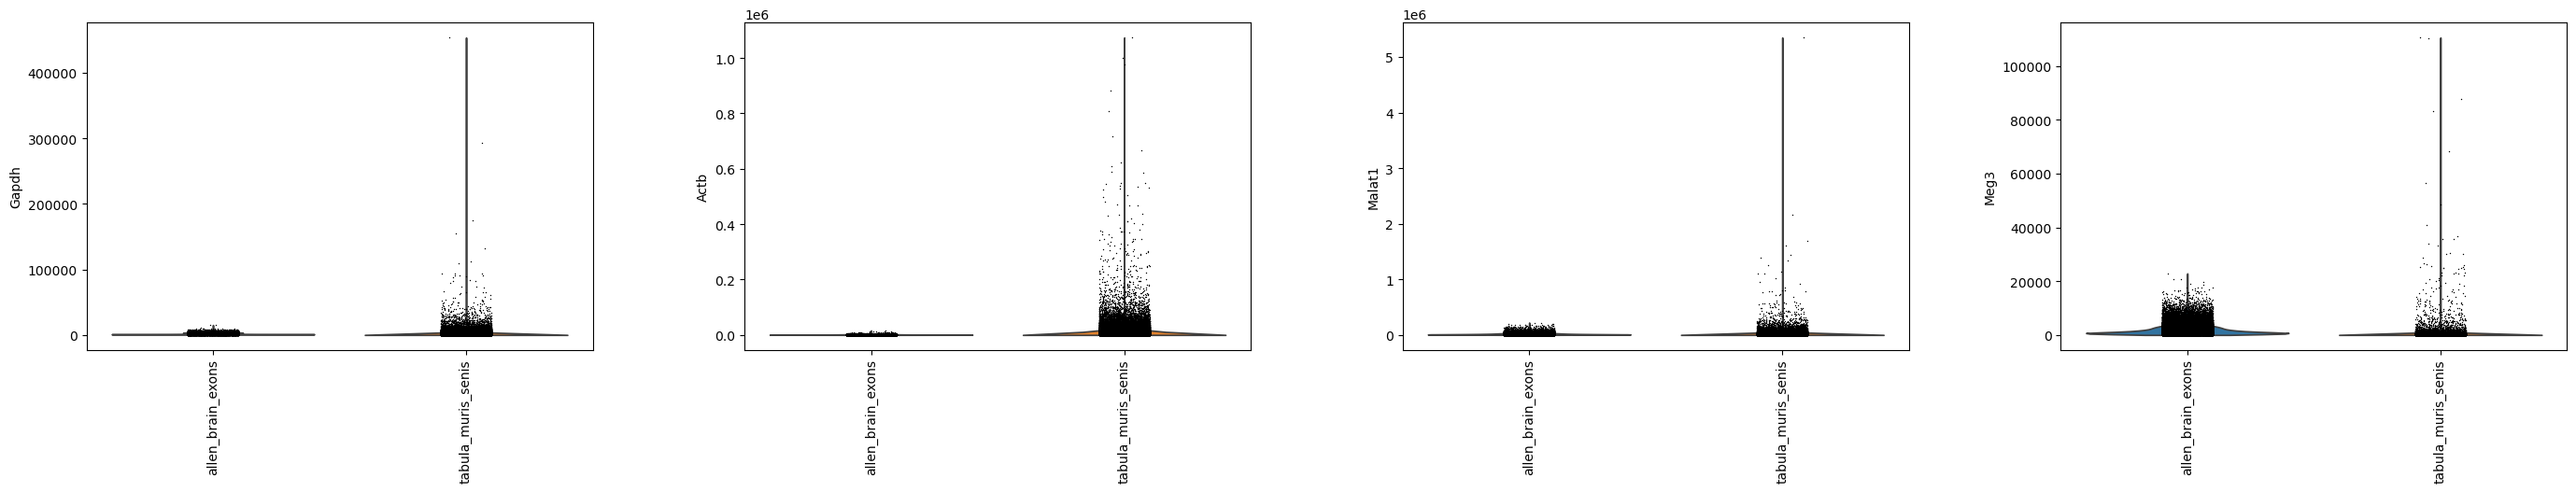

In [6]:
sc.pp.calculate_qc_metrics(ge_adata, inplace=True)
genes_of_interest = ['Gapdh', 'Actb', 'Malat1', 'Meg3']  # Add more based on your data

sc.pl.violin(ge_adata, keys=genes_of_interest, groupby='batch', rotation=90)

In [7]:
qc_metrics = ge_adata.obs[['n_genes_by_counts', 'library_size','batch']]

# Group by source and describe
summary = qc_metrics.groupby('batch').describe().round(2)
summary_stats = summary.stack().unstack(level=1)  # cleaner for display
display(summary_stats)

/scratch/ipykernel_3339502/2726209068.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = qc_metrics.groupby('batch').describe().round(2)
/scratch/ipykernel_3339502/2726209068.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  summary_stats = summary.stack().unstack(level=1)  # cleaner for display


n_genes_by_counts                                    \
                               count     mean      std     min     25%   
batch                                                                    
allen_brain_exons            51244.0  6654.77  1301.43  1229.0  5962.0   
tabula_muris_senis          106174.0  2377.40  1290.51   438.0  1410.0   

                                            library_size                   \
                       50%     75%      max        count    mean      std   
batch                                                                       
allen_brain_exons   6831.0  7539.0  10519.0      51244.0  765.82   476.94   
tabula_muris_senis  2087.0  3133.0   9175.0     106174.0  779.80  1231.61   

                                                              
                      min     25%     50%      75%       max  
batch                                                         
allen_brain_exons   35.25  356.81  522.55  1211.21   5858.18  
tabula_muris_senis   0.71  256.79  520.45   920.71  84348.50

In [8]:
# Set thresholds
min_genes = 500
max_genes = 10000
min_counts = 1e5
max_counts = 5e6

# Create filters
gene_filter = (ge_adata.obs['n_genes_by_counts'] >= min_genes) & (ge_adata.obs['n_genes_by_counts'] <= max_genes)
count_filter = (ge_adata.obs['total_counts'] >= min_counts) & (ge_adata.obs['total_counts'] <= max_counts)

# Remove cells with NA in broad_cell_type
label_filter = ge_adata.obs['broad_cell_type'].notna()

# Combine filters
combined_filter = gene_filter & count_filter & label_filter

# Report how many cells are retained
print(f"Cells before filtering: {ge_adata.n_obs}")
print(f"Cells after filtering: {np.sum(combined_filter)}")

# Apply the filter
ge_adata = ge_adata[combined_filter].copy()

Cells before filtering: 157418
Cells after filtering: 145981


In [9]:
# Step 1: Find top 10,000 highly variable genes using predicted_log_norm_tms
sc.pp.highly_variable_genes(
    ge_adata, 
    layer="predicted_log_norm_tms", 
    n_top_genes=10000, 
    inplace=True
)

# Print how many HVGs were found (should be 10,000)
n_hvgs = np.sum(ge_adata.var['highly_variable'])
print(f"Number of highly variable genes: {n_hvgs}")

# Subset to HVGs only
ge_adata = ge_adata[:, ge_adata.var['highly_variable']].copy()
print(f"Subset AnnData shape: {ge_adata.shape}")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:305: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


Number of highly variable genes: 10000
Subset AnnData shape: (145981, 10000)


In [10]:
import os
from datetime import datetime

# Set new model date and shared output directory
new_model_date = "062025"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
GE_OUTPUT_DIR = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/{new_model_date}"
os.makedirs(GE_OUTPUT_DIR, exist_ok=True)

# ---- Gene Expression ----
GE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/052025/aligned_gene_expression_data_20250513_035938.h5ad"
ge_filename = os.path.basename(GE_INPUT)
ge_new_filename = ge_filename.replace("20250513_035938", timestamp)
GE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, ge_new_filename)

# Save filtered gene expression data
ge_adata.write(GE_OUTPUT_PATH)
print(f"Filtered gene expression AnnData written to:\n{GE_OUTPUT_PATH}")

# ---- Splicing Data ----
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/052025/aligned_splicing_data_20250513_035938.h5ad"
splice_filename = os.path.basename(SPLICE_INPUT)
splice_new_filename = splice_filename.replace("20250513_035938", timestamp)
SPLICE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, splice_new_filename)

# Subset and save matched splicing data
splice_adata = splice_adata[ge_adata.obs_names].copy()
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values)
splice_adata.write(SPLICE_OUTPUT_PATH)
print(f"Filtered splicing AnnData written to:\n{SPLICE_OUTPUT_PATH}")

Filtered gene expression AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/aligned_gene_expression_data_20250614_193424.h5ad
Filtered splicing AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/aligned_splicing_data_20250614_193424.h5ad


In [11]:
# Save also text file with just final list of cell ids 
with open(os.path.join(GE_OUTPUT_DIR, "filtered_cell_ids.txt"), "w") as f:
    for cell_id in ge_adata.obs_names:
        f.write(f"{cell_id}\n")

In [14]:
splice_adata.var_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '34835', '34836', '34837', '34838', '34839', '34840', '34841', '34842',
       '34843', '34844'],
      dtype='object', length=34845)